# Exploratory Data Analysis
## Predicting IUCN Red List Categories for Data Deficient Species

This notebook explores the processed IUCN species data to understand patterns, distributions, and relationships that will inform our classification model. The goal is to predict the Red List category for **Data Deficient** species using features from non-DD species as training data.

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as mn

sns.set_theme(style="white")
plt.rcParams['figure.figsize'] = (12, 6)

## 1. Load Data & Basic Overview

In [42]:
base_taxa = pd.read_csv(r"../data/processed/base_taxa.csv")
conservation_needed = pd.read_csv(r"../data/processed/conservation_needed.csv")
countries = pd.read_csv(r"../data/processed/countries.csv")
habitats = pd.read_csv(r"../data/processed/habitats.csv")
research_needed = pd.read_csv(r"../data/processed/research_needed.csv")
threats = pd.read_csv(r"../data/processed/threats.csv")
uses = pd.read_csv(r"../data/processed/uses.csv")

datasets = {
    'base_taxa': base_taxa,
    'countries': countries,
    'habitats': habitats,
    'threats': threats,
    'research_needed': research_needed,
    'conservation_needed': conservation_needed,
    'uses': uses
}

for name, df in datasets.items():
    print(f"{name:25s} {df.shape[0]:>7,} rows, {df.shape[1]:>2} columns")

base_taxa                  39,024 rows, 12 columns
countries                 431,396 rows,  4 columns
habitats                  109,594 rows,  3 columns
threats                    88,999 rows,  3 columns
research_needed            82,263 rows,  3 columns
conservation_needed        50,414 rows,  3 columns
uses                       18,524 rows,  3 columns


In [43]:
base_taxa.head()

,assessmentId,internalTaxonId,scientificName,kingdomName,phylumName,orderName,className,familyName,genusName,speciesName,redlistCategory,populationTrend
0,495630,10030,Hexanchus griseus,ANIMALIA,CHORDATA,HEXANCHIFORMES,CHONDRICHTHYES,HEXANCHIDAE,Hexanchus,griseus,Near Threatened,Decreasing
1,500969,11200,Lamna nasus,ANIMALIA,CHORDATA,LAMNIFORMES,CHONDRICHTHYES,LAMNIDAE,Lamna,nasus,Vulnerable,Decreasing
2,507158,232775771,Macrochelys temminckii,ANIMALIA,CHORDATA,TESTUDINES,REPTILIA,CHELYDRIDAE,Macrochelys,temminckii,Endangered,Decreasing
3,508210,12696,Malacochersus tornieri,ANIMALIA,CHORDATA,TESTUDINES,REPTILIA,TESTUDINIDAE,Malacochersus,tornieri,Critically Endangered,Decreasing
4,508612,12776,Mantella aurantiaca,ANIMALIA,CHORDATA,ANURA,AMPHIBIA,MANTELLIDAE,Mantella,aurantiaca,Endangered,Decreasing


## 2. Target Variable: Red List Category

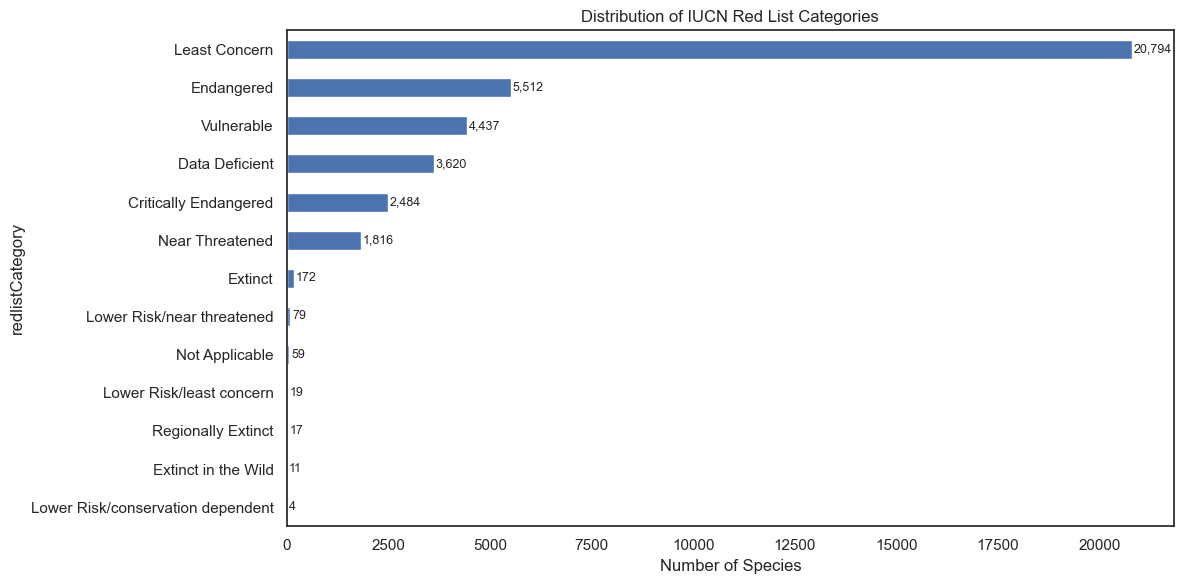


Total species: 39,024
Data Deficient species: 3,620


In [44]:
category_counts = base_taxa['redlistCategory'].value_counts()

fig, ax = plt.subplots(figsize=(12, 6))
category_counts.plot(kind='barh', ax=ax)
ax.set_xlabel('Number of Species')
ax.set_title('Distribution of IUCN Red List Categories')
ax.invert_yaxis()

# value counts
for i, v in enumerate(category_counts.values):
    ax.text(v + 50, i, f'{v:,}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nTotal species: {len(base_taxa):,}")
print(f"Data Deficient species: {(base_taxa['redlistCategory'] == 'Data Deficient').sum():,}")

There are 13 different Red List categories with a heavily imbalanced distribution — **Least Concern** dominates. For a capstone-level classification project, we can simplify these into broader groups:

- **Threatened**: Vulnerable, Endangered, Critically Endangered
- **Non-Threatened**: Least Concern, Near Threatened, Lower Risk/*
- **Extinct**: Extinct, Extinct in the Wild, Regionally Extinct
- **Data Deficient**: Our prediction target (excluded from training)

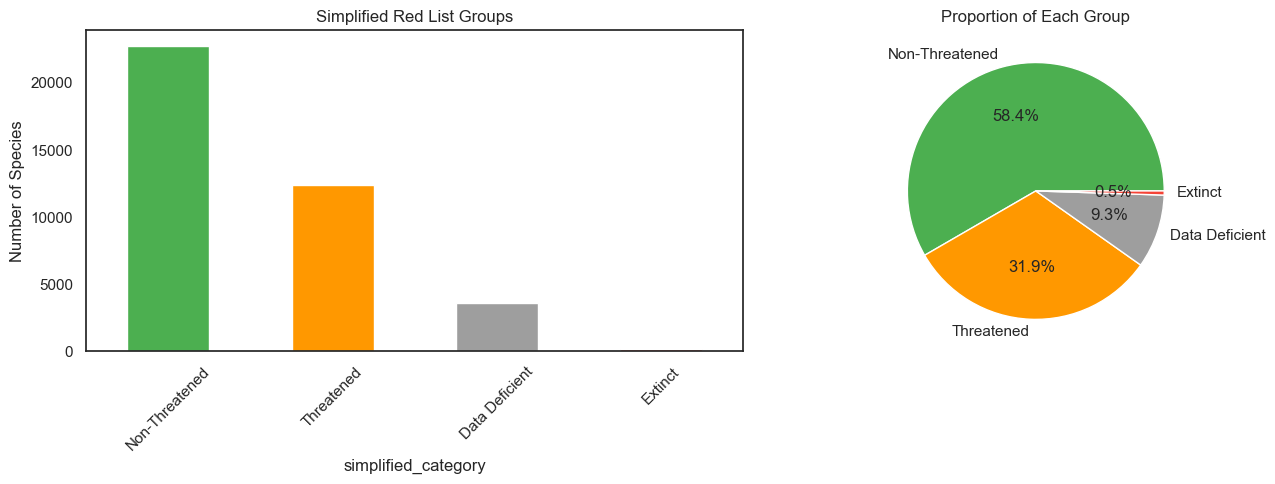

simplified_category
Non-Threatened    22771
Threatened        12433
Data Deficient     3620
Extinct             200
Name: count, dtype: int64

In [45]:
# Create simplified category grouping
def simplify_category(cat):
    threatened = ['Vulnerable', 'Endangered', 'Critically Endangered']
    non_threatened = ['Least Concern', 'Near Threatened', 'Not Applicable',
                      'Lower Risk/near threatened', 'Lower Risk/least concern',
                      'Lower Risk/conservation dependent']
    extinct = ['Extinct', 'Extinct in the Wild', 'Regionally Extinct']
    
    if cat in threatened:
        return 'Threatened'
    elif cat in non_threatened:
        return 'Non-Threatened'
    elif cat in extinct:
        return 'Extinct'
    else:
        return 'Data Deficient'

base_taxa['simplified_category'] = base_taxa['redlistCategory'].apply(simplify_category)

# Plot simplified distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Simplified categories
simplified_counts = base_taxa['simplified_category'].value_counts()
colors = {'Non-Threatened': '#4CAF50', 'Threatened': '#FF9800', 'Data Deficient': '#9E9E9E', 'Extinct': '#F44336'}
bar_colors = [colors[cat] for cat in simplified_counts.index]
simplified_counts.plot(kind='bar', color=bar_colors, ax=axes[0])
axes[0].set_title('Simplified Red List Groups')
axes[0].set_ylabel('Number of Species')
axes[0].tick_params(axis='x', rotation=45)

# Percentage breakdown
simplified_counts.plot(kind='pie', autopct='%1.1f%%', colors=bar_colors, ax=axes[1])
axes[1].set_ylabel('')
axes[1].set_title('Proportion of Each Group')

plt.tight_layout()
plt.show()

simplified_counts

**Key observation:** The dataset is heavily imbalanced. For modelling, we will:
1. Train on non-DD species only (using simplified categories: Threatened, Non-Threatened, Extinct)
2. Predict the most likely category for each Data Deficient species
3. Need to handle class imbalance (e.g., oversampling, class weights)

## 3. Taxonomic Feature Exploration

Taxonomy (phylum, class, order, family) may be a strong predictor — certain groups of animals or plants tend to be more threatened than others.

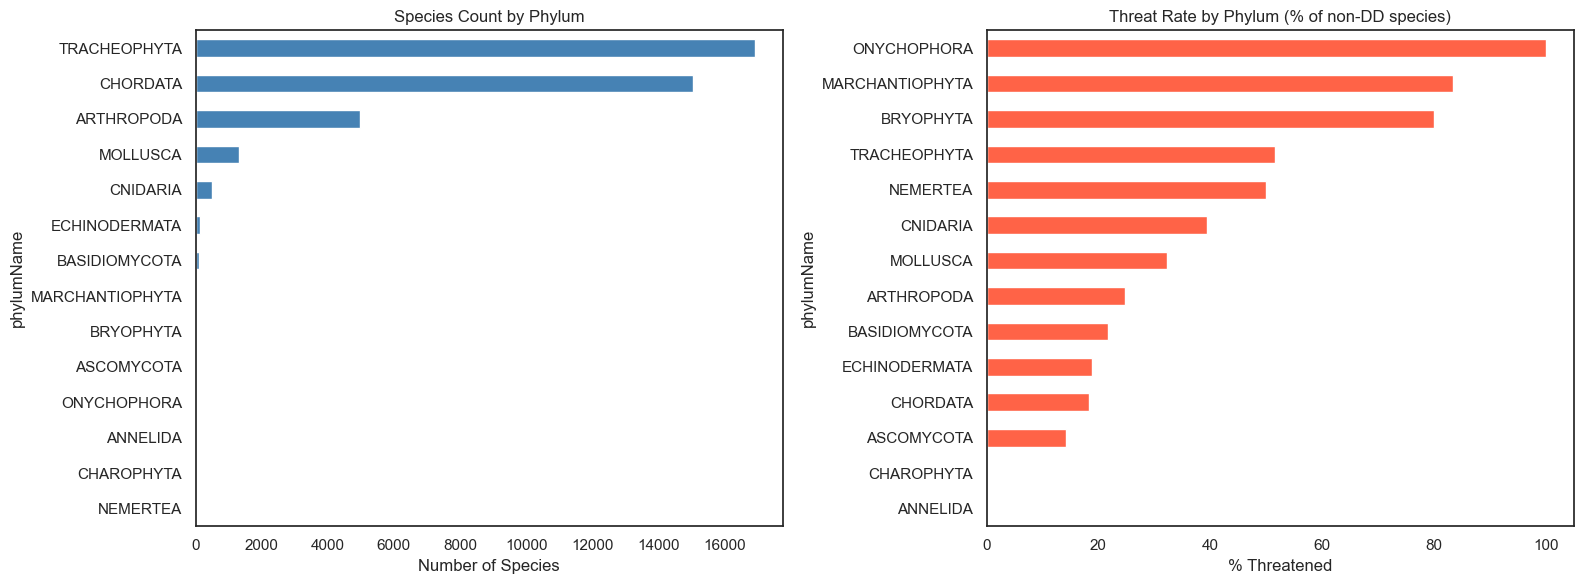

In [46]:
# Distribution across phyla
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Count per phylum
phylum_counts = base_taxa['phylumName'].value_counts()
phylum_counts.plot(kind='barh', color='steelblue', ax=axes[0])
axes[0].set_title('Species Count by Phylum')
axes[0].set_xlabel('Number of Species')
axes[0].invert_yaxis()

# Threat rate by phylum (excluding DD)
non_dd = base_taxa[base_taxa['simplified_category'] != 'Data Deficient']
threat_rate = non_dd.groupby('phylumName')['simplified_category'].apply(
    lambda x: (x == 'Threatened').mean() * 100
).sort_values(ascending=False)

threat_rate.plot(kind='barh', color='tomato', ax=axes[1])
axes[1].set_title('Threat Rate by Phylum (% of non-DD species)')
axes[1].set_xlabel('% Threatened')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

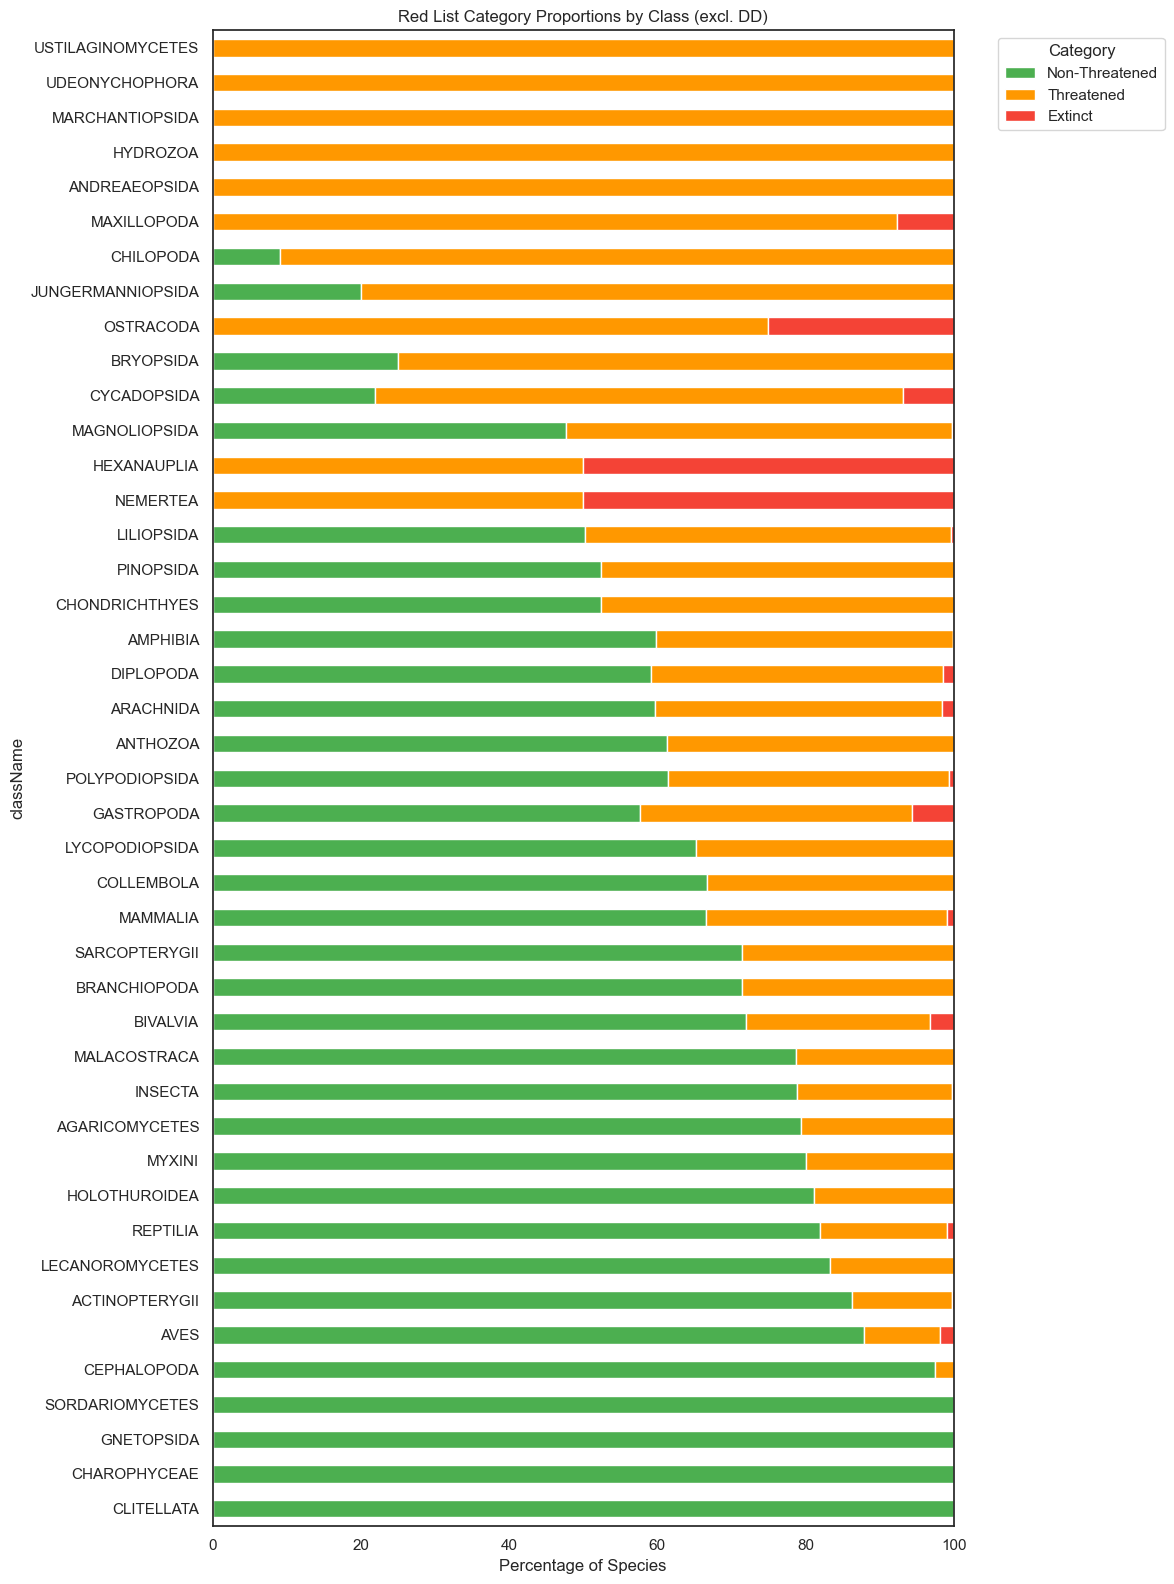

In [71]:
# Stacked bar: simplified category proportions within each class
top_classes = base_taxa['className'].value_counts().index
class_subset = non_dd[non_dd['className'].isin(top_classes)]

ct = pd.crosstab(class_subset['className'], class_subset['simplified_category'], normalize='index') * 100

ct = ct[['Non-Threatened', 'Threatened', 'Extinct']]
ct = ct.sort_values('Threatened', ascending=True)

ct.plot(kind='barh', stacked=True, figsize=(12, 16),
        color=['#4CAF50', '#FF9800', '#F44336'])
plt.title('Red List Category Proportions by Class (excl. DD)')
plt.xlabel('Percentage of Species')
plt.legend(title='Category', bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

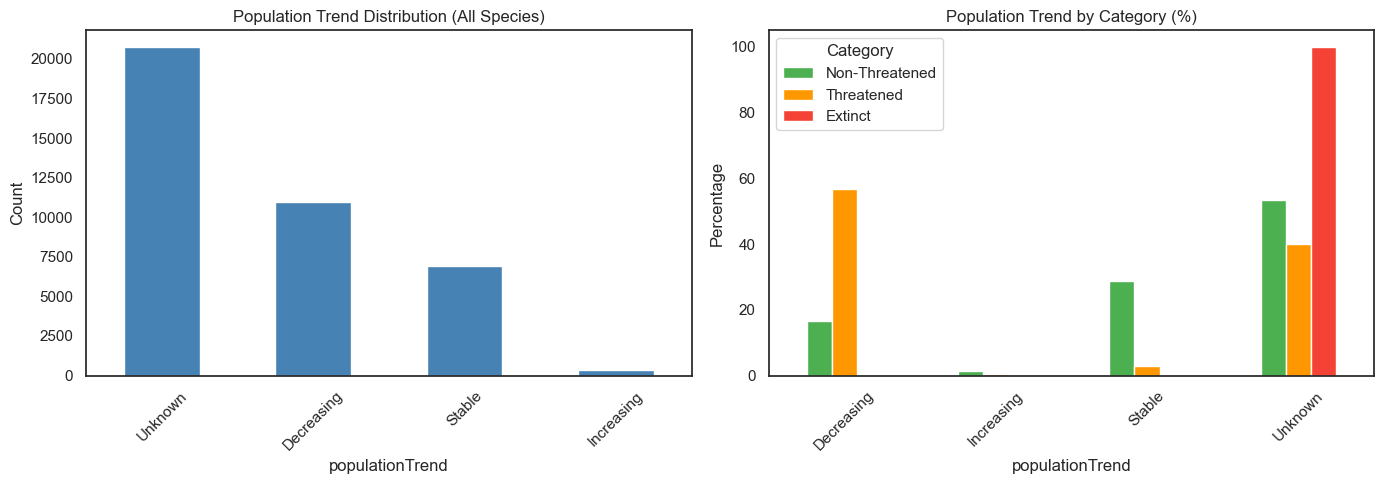

In [48]:
# Population trend distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overall
base_taxa['populationTrend'].value_counts().plot(kind='bar', color='steelblue', ax=axes[0])
axes[0].set_title('Population Trend Distribution (All Species)')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

# By simplified category
trend_ct = pd.crosstab(non_dd['populationTrend'], non_dd['simplified_category'], normalize='columns') * 100
trend_ct[['Non-Threatened', 'Threatened', 'Extinct']].plot(
    kind='bar', ax=axes[1], color=['#4CAF50', '#FF9800', '#F44336'])
axes[1].set_title('Population Trend by Category (%)')
axes[1].set_ylabel('Percentage')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(title='Category')

plt.tight_layout()
plt.show()

**Observations:**
- Taxonomic group matters: Some classes (e.g., Amphibia, Reptilia) tend to have higher threat rates than others (e.g., Insecta)
- Population trend is a strong signal: Threatened species are much more likely to have "Decreasing" trends, while non-threatened species tend to be "Stable" or "Unknown"
- Most DD species likely have "Unknown" population trends, so this feature may have limited predictive power for them

## 4. Geographic Patterns

Species that occur in fewer countries may have smaller ranges and be more vulnerable to threats.

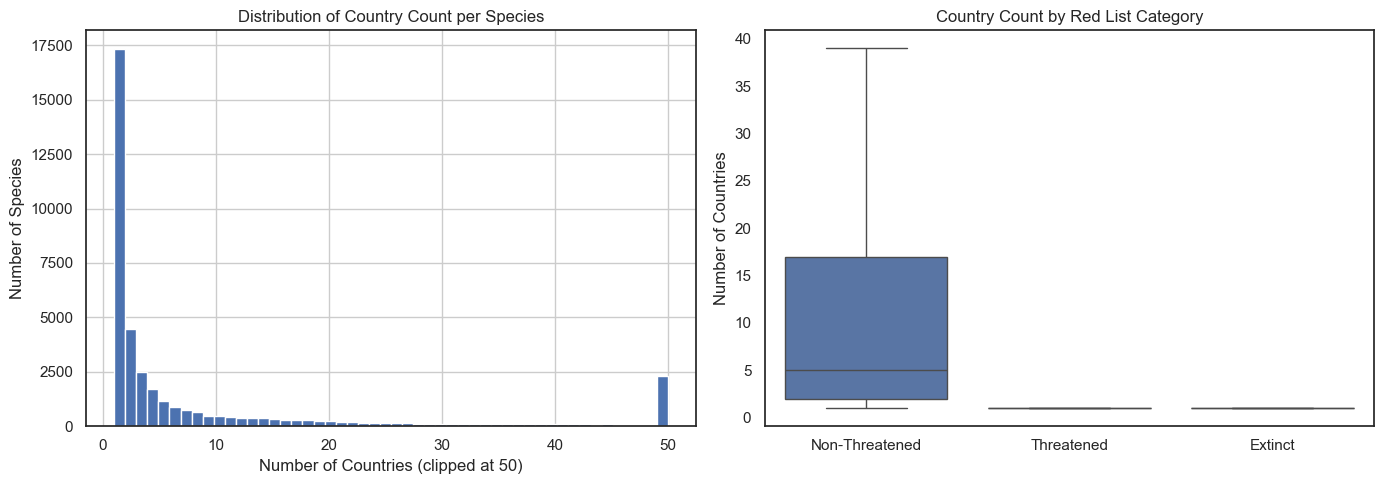

Median country count by category:
simplified_category
Data Deficient    1.0
Extinct           1.0
Threatened        1.0
Non-Threatened    5.0
Name: n_countries, dtype: float64


In [49]:
# Number of countries per species
country_counts = countries.groupby('internalTaxonId').size().reset_index(name='n_countries')
base_merged = base_taxa.merge(country_counts, on='internalTaxonId', how='left')
base_merged['n_countries'] = base_merged['n_countries'].fillna(0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram of country counts
base_merged['n_countries'].clip(upper=50).hist(bins=50, ax=axes[0])
axes[0].set_title('Distribution of Country Count per Species')
axes[0].set_xlabel('Number of Countries (clipped at 50)')
axes[0].set_ylabel('Number of Species')

# Boxplot by simplified category
plot_data = base_merged[base_merged['simplified_category'] != 'Data Deficient']
order = ['Non-Threatened', 'Threatened', 'Extinct']
sns.boxplot(data=plot_data, x='simplified_category', y='n_countries', order=order, ax=axes[1], showfliers=False)
axes[1].set_title('Country Count by Red List Category')
axes[1].set_ylabel('Number of Countries')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

# Median country count by category
print("Median country count by category:")
print(base_merged.groupby('simplified_category')['n_countries'].median().sort_values())

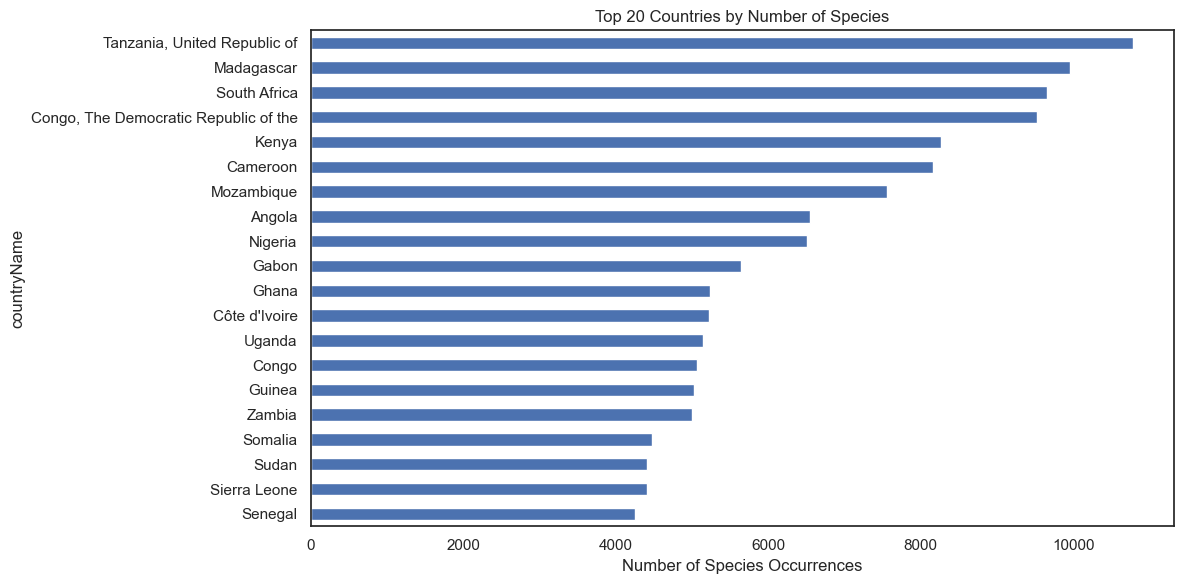

In [70]:
top_countries = countries.groupby('countryName').size().sort_values(ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 6))
top_countries.plot(kind='barh', ax=ax)
ax.set_title('Top 20 Countries by Number of Species')
ax.set_xlabel('Number of Species Occurrences')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 5. Habitat Analysis

Species that inhabit fewer habitat types (habitat specialists) may be more vulnerable to environmental changes.

In [51]:
habitats.head()

,internalTaxonId,habitatCode,habitatName
0,199057,11.1.2,Soft Substrate
1,199080,9.9,Marine Neritic - Seagrass (Submerged)
2,199080,9.3,Marine Neritic - Subtidal Loose Rock/pebble/gr...
3,199080,9.4,Marine Neritic - Subtidal Sandy
4,199080,9.8.4,Lagoon


In [52]:
base_merged.head()

,assessmentId,internalTaxonId,scientificName,kingdomName,phylumName,orderName,className,familyName,genusName,speciesName,redlistCategory,populationTrend,simplified_category,n_countries
0,495630,10030,Hexanchus griseus,ANIMALIA,CHORDATA,HEXANCHIFORMES,CHONDRICHTHYES,HEXANCHIDAE,Hexanchus,griseus,Near Threatened,Decreasing,Non-Threatened,76
1,500969,11200,Lamna nasus,ANIMALIA,CHORDATA,LAMNIFORMES,CHONDRICHTHYES,LAMNIDAE,Lamna,nasus,Vulnerable,Decreasing,Threatened,47
2,507158,232775771,Macrochelys temminckii,ANIMALIA,CHORDATA,TESTUDINES,REPTILIA,CHELYDRIDAE,Macrochelys,temminckii,Endangered,Decreasing,Threatened,9
3,508210,12696,Malacochersus tornieri,ANIMALIA,CHORDATA,TESTUDINES,REPTILIA,TESTUDINIDAE,Malacochersus,tornieri,Critically Endangered,Decreasing,Threatened,3
4,508612,12776,Mantella aurantiaca,ANIMALIA,CHORDATA,ANURA,AMPHIBIA,MANTELLIDAE,Mantella,aurantiaca,Endangered,Decreasing,Threatened,1


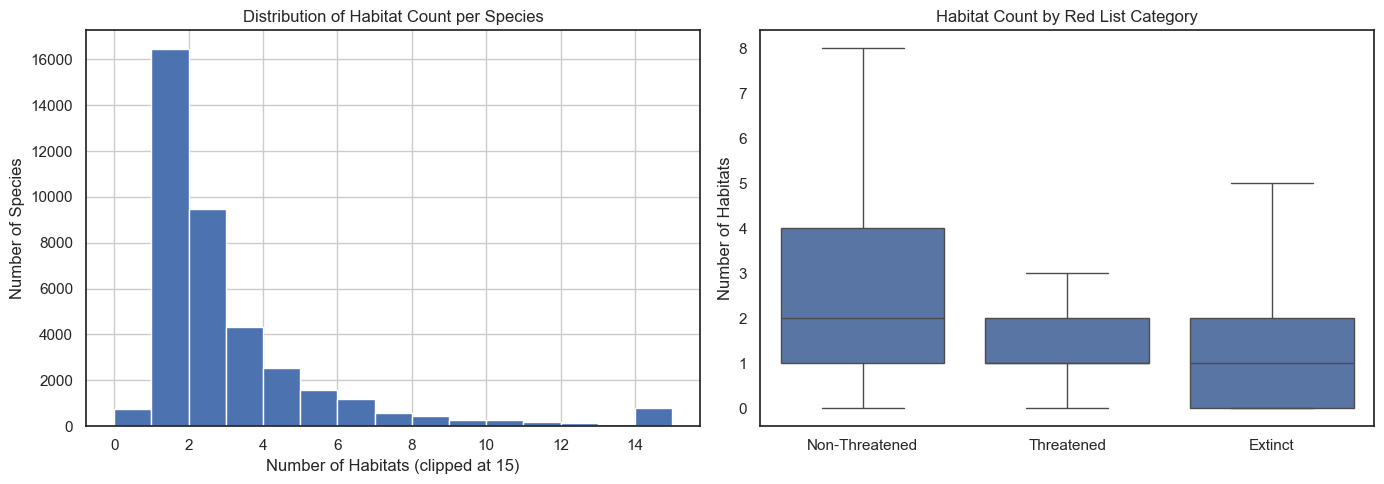

Median habitat count by category:
simplified_category
Data Deficient    1.0
Extinct           1.0
Threatened        1.0
Non-Threatened    2.0
Name: n_habitats, dtype: float64


In [53]:
# Number of habitats per species
habitat_counts = habitats.groupby('internalTaxonId').size().reset_index(name='n_habitats')
base_merged = base_merged.merge(habitat_counts, on='internalTaxonId', how='left')
base_merged['n_habitats'] = base_merged['n_habitats'].fillna(0).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
base_merged['n_habitats'].clip(upper=15).hist(bins=15, ax=axes[0])
axes[0].set_title('Distribution of Habitat Count per Species')
axes[0].set_xlabel('Number of Habitats (clipped at 15)')
axes[0].set_ylabel('Number of Species')

# Boxplot by category
plot_data = base_merged[base_merged['simplified_category'] != 'Data Deficient']
sns.boxplot(data=plot_data, x='simplified_category', y='n_habitats', order=order, ax=axes[1], showfliers=False)
axes[1].set_title('Habitat Count by Red List Category')
axes[1].set_ylabel('Number of Habitats')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

print("Median habitat count by category:")
print(base_merged.groupby('simplified_category')['n_habitats'].median().sort_values())

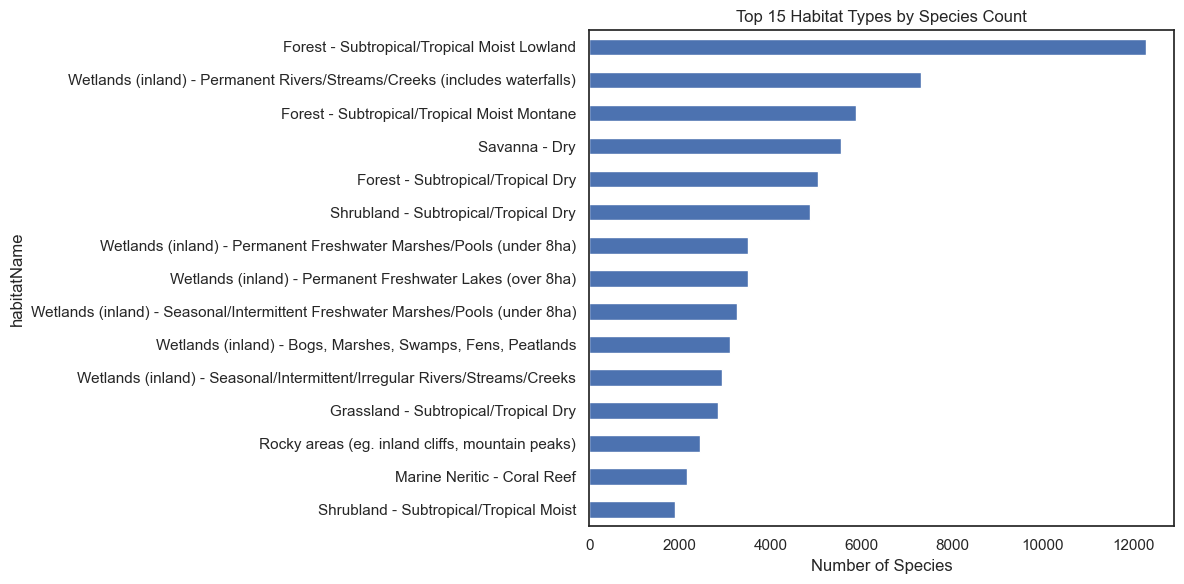

In [54]:
# Top 15 habitat types
top_habitats = habitats['habitatName'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
top_habitats.plot(kind='barh', ax=ax)
ax.set_title('Top 15 Habitat Types by Species Count')
ax.set_xlabel('Number of Species')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

## 6. Threats Analysis

The number and types of threats a species faces can indicate its vulnerability level.

In [55]:
# Number of threats per species
threat_counts = threats.groupby('internalTaxonId').size().reset_index(name='n_threats')
base_merged = base_merged.merge(threat_counts, on='internalTaxonId', how='left')
base_merged['n_threats'] = base_merged['n_threats'].fillna(0).astype(int)

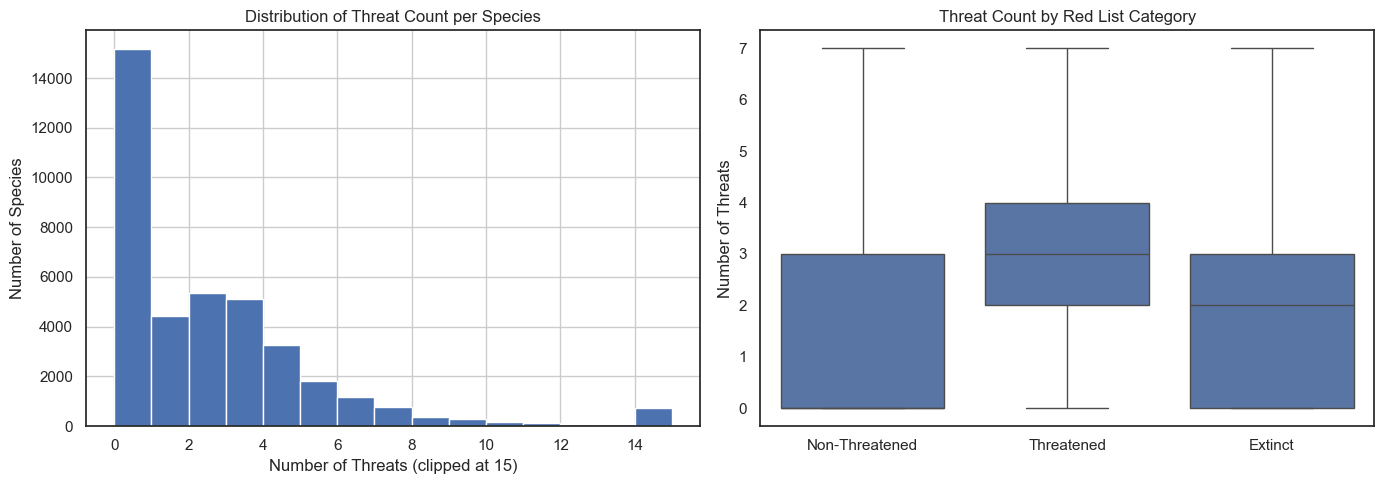

Median threat count by category:
simplified_category
Data Deficient    0.0
Non-Threatened    0.0
Extinct           2.0
Threatened        3.0
Name: n_threats, dtype: float64


In [60]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
base_merged['n_threats'].clip(upper=15).hist(bins=15, ax=axes[0])
axes[0].set_title('Distribution of Threat Count per Species')
axes[0].set_xlabel('Number of Threats (clipped at 15)')
axes[0].set_ylabel('Number of Species')

# Boxplot by category
plot_data = base_merged[base_merged['simplified_category'] != 'Data Deficient']
sns.boxplot(data=plot_data, x='simplified_category', y='n_threats', order=order, ax=axes[1], showfliers=False)
axes[1].set_title('Threat Count by Red List Category')
axes[1].set_ylabel('Number of Threats')
axes[1].set_xlabel('')

plt.tight_layout()
plt.show()

print("Median threat count by category:")
print(base_merged.groupby('simplified_category')['n_threats'].median().sort_values())

## 7. Uses, Conservation Actions & Research Needed

In [61]:
# Merge remaining count features
use_counts = uses.groupby('internalTaxonId').size().reset_index(name='n_uses')
cons_counts = conservation_needed.groupby('internalTaxonId').size().reset_index(name='n_conservation')
research_counts = research_needed.groupby('internalTaxonId').size().reset_index(name='n_research')

base_merged = base_merged.merge(use_counts, on='internalTaxonId', how='left')
base_merged = base_merged.merge(cons_counts, on='internalTaxonId', how='left')
base_merged = base_merged.merge(research_counts, on='internalTaxonId', how='left')

for col in ['n_uses', 'n_conservation', 'n_research']:
    base_merged[col] = base_merged[col].fillna(0).astype(int)

C:\Users\HP\AppData\Local\Temp\ipykernel_4192\3616947557.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='simplified_category', y=col, order=order,
C:\Users\HP\AppData\Local\Temp\ipykernel_4192\3616947557.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='simplified_category', y=col, order=order,
C:\Users\HP\AppData\Local\Temp\ipykernel_4192\3616947557.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=plot_data, x='simplified_category', y=col, order=order,


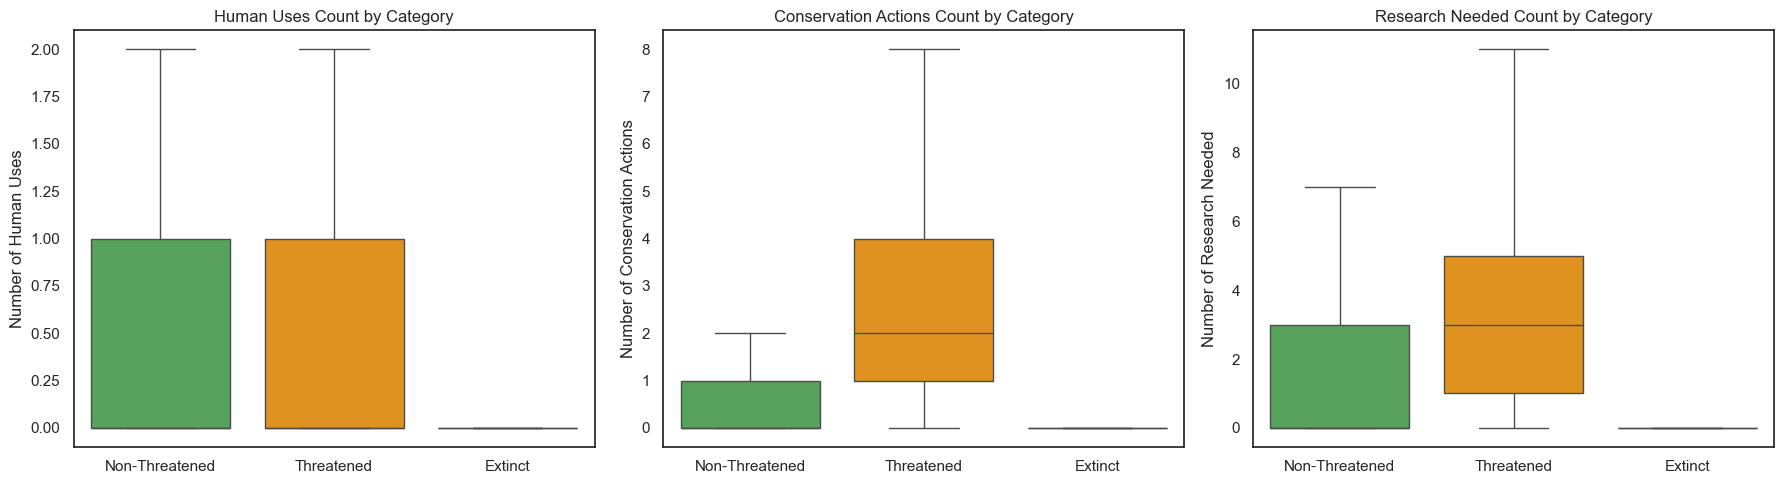

In [62]:
# Plot distributions by category
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col, title, color in zip(axes,
    ['n_uses', 'n_conservation', 'n_research'],
    ['Human Uses', 'Conservation Actions', 'Research Needed'],
    ['purple', 'teal', 'orange']):
    
    plot_data = base_merged[base_merged['simplified_category'] != 'Data Deficient']
    sns.boxplot(data=plot_data, x='simplified_category', y=col, order=order,
                palette=['#4CAF50', '#FF9800', '#F44336'], ax=ax, showfliers=False)
    ax.set_title(f'{title} Count by Category')
    ax.set_ylabel(f'Number of {title}')
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

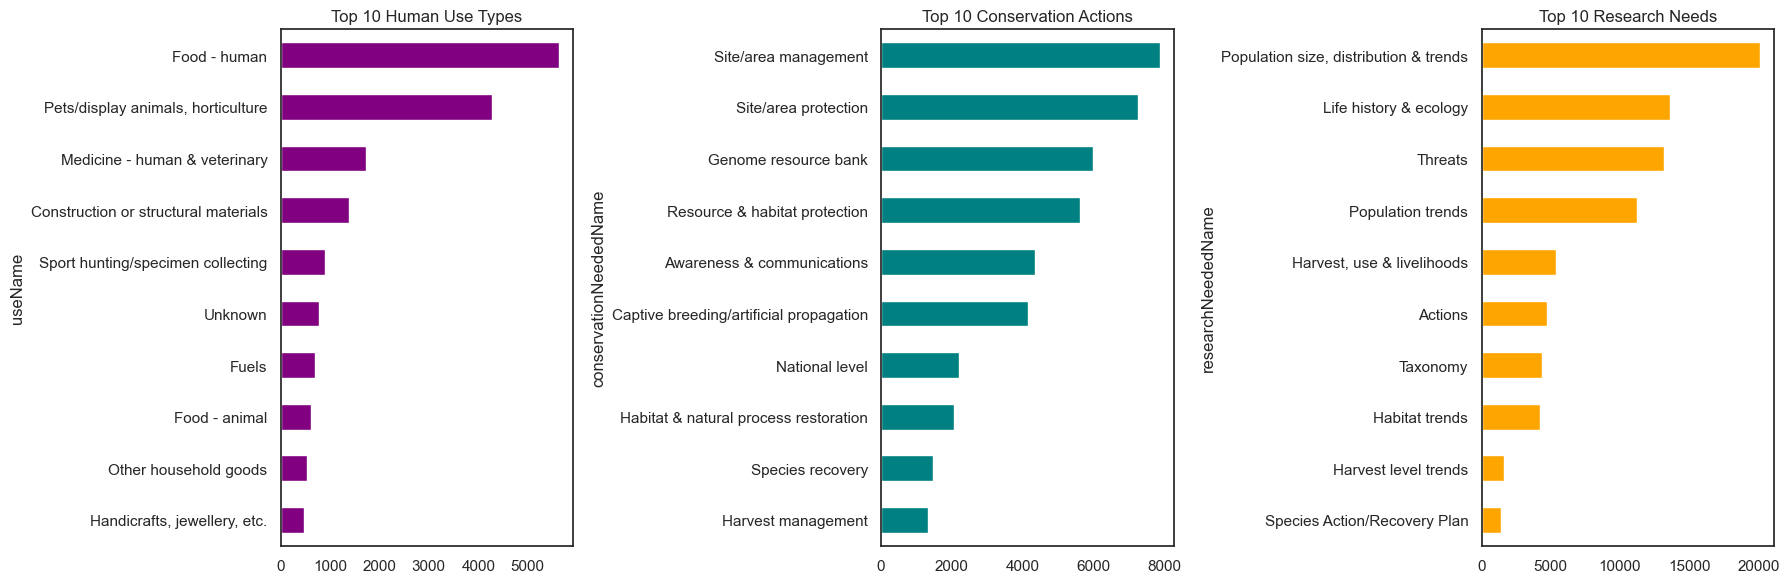

In [63]:
# Top use types, conservation actions, and research needs
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

uses['useName'].value_counts().head(10).plot(kind='barh', color='purple', ax=axes[0])
axes[0].set_title('Top 10 Human Use Types')
axes[0].invert_yaxis()

conservation_needed['conservationNeededName'].value_counts().head(10).plot(kind='barh', color='teal', ax=axes[1])
axes[1].set_title('Top 10 Conservation Actions')
axes[1].invert_yaxis()

research_needed['researchNeededName'].value_counts().head(10).plot(kind='barh', color='orange', ax=axes[2])
axes[2].set_title('Top 10 Research Needs')
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

## 9. Data Availability for Data Deficient Species

This is a critical check: for each relational table, what percentage of DD species actually have data? If a feature is missing for most DD species, it won't be useful for prediction.

In [64]:
# Data availability: % of DD vs non-DD species with at least one entry in each table
dd_ids = set(base_taxa[base_taxa['redlistCategory'] == 'Data Deficient']['internalTaxonId'])
non_dd_ids = set(base_taxa[base_taxa['redlistCategory'] != 'Data Deficient']['internalTaxonId'])

tables = {
    'countries': countries,
    'habitats': habitats,
    'threats': threats,
    'uses': uses,
    'conservation_needed': conservation_needed,
    'research_needed': research_needed,
}

availability = []
for name, df in tables.items():
    ids_in_table = set(df['internalTaxonId'].unique())
    dd_pct = len(ids_in_table & dd_ids) / len(dd_ids) * 100
    non_dd_pct = len(ids_in_table & non_dd_ids) / len(non_dd_ids) * 100
    availability.append({'Table': name, 'DD Species (%)': round(dd_pct, 1), 'Non-DD Species (%)': round(non_dd_pct, 1)})

avail_df = pd.DataFrame(availability)
print(f"Total DD species: {len(dd_ids):,}")
print(f"Total non-DD species: {len(non_dd_ids):,}\n")
avail_df

Total DD species: 3,620
Total non-DD species: 35,404



,Table,DD Species (%),Non-DD Species (%)
0,countries,100.0,100.0
1,habitats,97.0,98.2
2,threats,35.4,63.8
3,uses,17.8,30.6
4,conservation_needed,20.2,44.9
5,research_needed,82.9,57.7


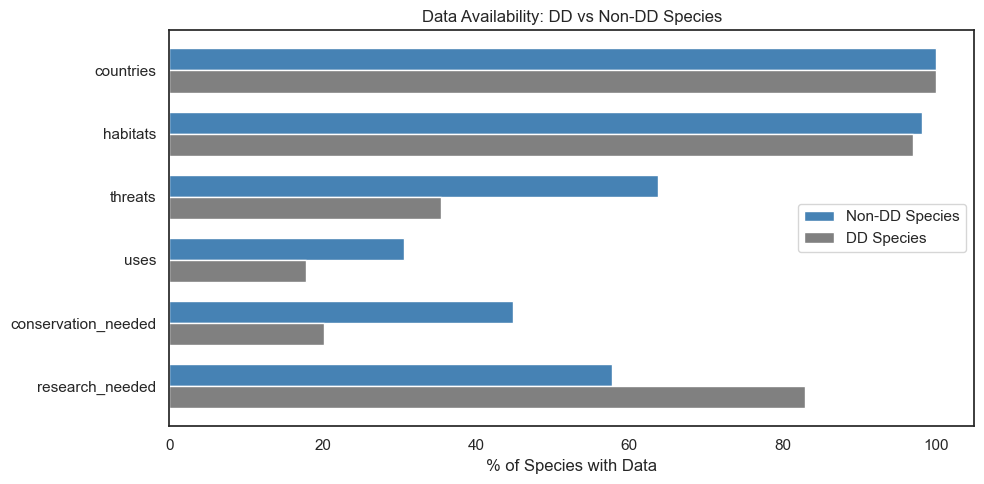

In [65]:
# Visualize the availability comparison
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(avail_df))
width = 0.35

ax.barh(x - width/2, avail_df['Non-DD Species (%)'], width, label='Non-DD Species', color='steelblue')
ax.barh(x + width/2, avail_df['DD Species (%)'], width, label='DD Species', color='grey')

ax.set_yticks(x)
ax.set_yticklabels(avail_df['Table'])
ax.set_xlabel('% of Species with Data')
ax.set_title('Data Availability: DD vs Non-DD Species')
ax.legend()
ax.set_xlim(0, 105)
ax.invert_yaxis()

plt.tight_layout()
plt.show()

## 10. Correlation Between Numeric Features

Let's check if the count-based features we've derived are correlated with each other.

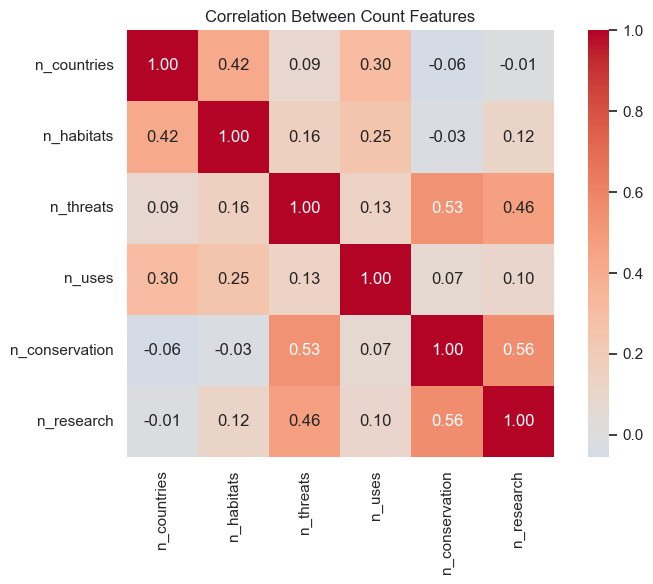

In [66]:
# Correlation heatmap of numeric count features
numeric_cols = ['n_countries', 'n_habitats', 'n_threats', 'n_uses', 'n_conservation', 'n_research']
corr = base_merged[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax, square=True)
ax.set_title('Correlation Between Count Features')
plt.tight_layout()
plt.show()

## 11. Key Takeaways & Feature Engineering Ideas

### Summary of Findings

1. **Class imbalance**: Least Concern dominates the dataset. We'll need strategies like class weights or oversampling (SMOTE) during modelling.

2. **Taxonomic features are informative**: Different phyla and classes have very different threat rates. `className`, `orderName`, and `familyName` should be strong categorical features.

3. **Population trend**: Strongly associated with threat level, but most DD species likely have "Unknown" trends, limiting its predictive utility.

4. **Geographic range (country count)**: Threatened species tend to occur in fewer countries than non-threatened ones. `n_countries` is a useful numeric feature.

5. **Habitat count**: Species in fewer habitats may be more vulnerable. `n_habitats` is a useful feature.

6. **Threat count**: Threatened species tend to have more documented threats. However, DD species may have fewer threats documented simply due to lack of data.

7. **Range data (AOO, EOO, elevation)**: Extremely sparse — likely too incomplete to use as features.

8. **DD data availability**: Critical to check which features are actually available for DD species before including them in the model.

### Candidate Features for Modelling

| Feature | Type | Source |
|---------|------|--------|
| `className` | Categorical | base_taxa |
| `populationTrend` | Categorical | base_taxa |
| `n_countries` | Numeric | countries (count) |
| `n_habitats` | Numeric | habitats (count) |
| `n_threats` | Numeric | threats (count) |
| `n_uses` | Numeric | uses (count) |
| `n_conservation` | Numeric | conservation_needed (count) |
| `n_research` | Numeric | research_needed (count) |
| Top-N habitat/threat flags | Binary | habitats, threats (one-hot presence) |

### Next Steps (Notebook 03)
- Build the feature matrix by joining count features and encoding categoricals
- Split non-DD species into train/test sets
- Handle class imbalance
- Train baseline models (Logistic Regression, Random Forest, etc.)
- Predict categories for Data Deficient species